# **GOAL**

Objective:
To segment mall customers into distinct groups based on their spending habits and demographics using unsupervised learning (K-Means clustering). This segmentation will help understand different customer profiles and enable the development of targeted marketing strategies to increase customer engagement and sales.

**Importing libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

**uploading the dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [ ]:
#importing the dataset
df = pd.read_csv('Mall_Customers.csv')
df.head() #first few rows of our csv

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# EDA

In [ ]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

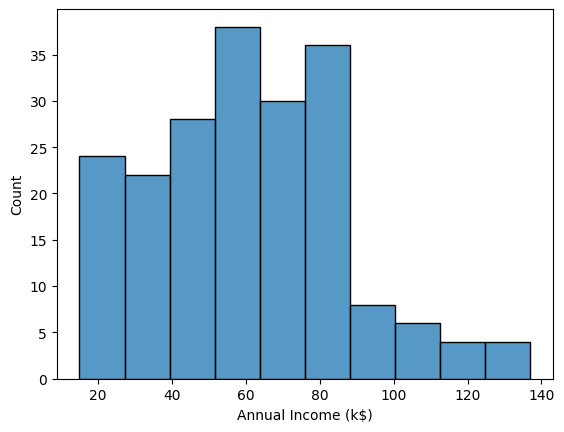

In [ ]:
#data viualization
sns.histplot(df['Annual Income (k$)'])

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

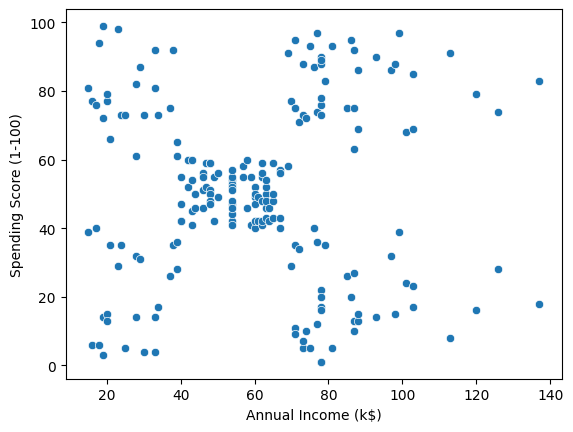

In [ ]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

# Feature Selection and Scaling


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Optimal clusters (Elbow Method)

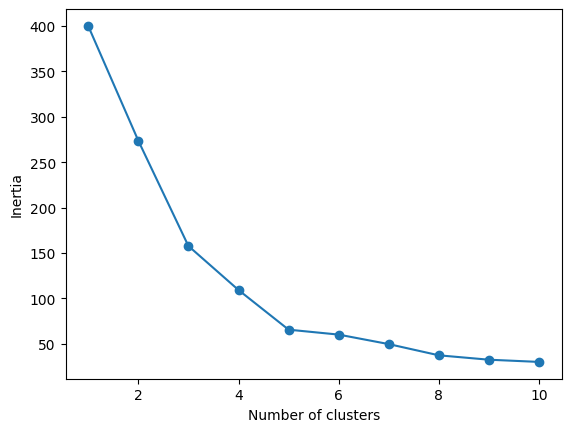

In [ ]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


# Fit KMeans with chosen k (e.g., k=5)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

# Visualization using PCA

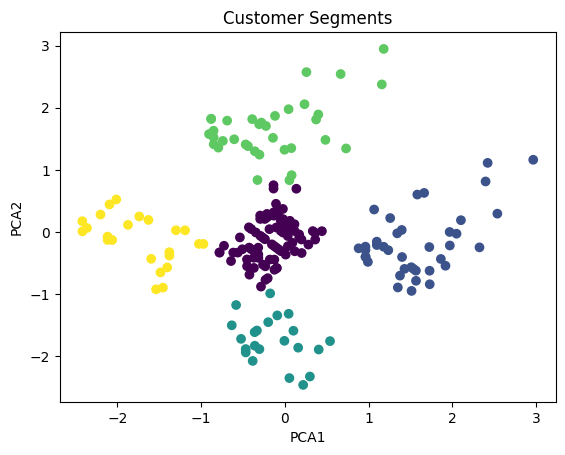

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Customer Segments')
plt.show()

# Summarize clusters for strategy

In [ ]:
# Only include numeric columns when calculating the mean
df.groupby('Cluster')[df.select_dtypes(include='number').columns].mean()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
Cluster,,,,,
0,86.320988,42.716049,55.296296,49.518519,0.0
1,162.000000,32.692308,86.538462,82.128205,1.0
2,23.090909,25.272727,25.727273,79.363636,2.0
3,164.371429,41.114286,88.200000,17.114286,3.0
4,23.000000,45.217391,26.304348,20.913043,4.0


# CONCLUSION

By calculating the mean values of numeric features such as Age, Annual Income, and Spending Score for each customer cluster, we can better understand the characteristics of each group. This analysis helps identify key patterns, such as which clusters consist of younger customers, which ones have higher income levels, or which groups are high spenders. These insights are essential for businesses to develop targeted marketing strategies tailored to the needs and behaviors of each segment. Ultimately, this approach enables more effective customer engagement and improved business outcomes.